# Import Library

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime
import xgboost as xgb
import os
import joblib

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Memuat Dataset

In [ ]:
# Membaca CSV dari link download langsung
market_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1oMmR6WObZNer4HEVjKLcqK0wbCpp89Bo')

market_df.head()

,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_sugar,c_sugar,inflation_sugar,trust_sugar,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
0,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-01-01,2007,...,9855.73,10080.27,NaN,8.8,0.62,0.63,0.62,0.62,NaN,9.2
1,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-02-01,2007,...,9888.89,10105.85,NaN,8.8,0.63,0.64,0.62,0.62,NaN,9.2
2,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-03-01,2007,...,9987.67,10237.43,NaN,8.8,0.62,0.63,0.61,0.63,NaN,9.2
3,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-04-01,2007,...,10101.85,10152.65,NaN,8.8,0.63,0.64,0.62,0.64,NaN,9.2
4,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2007-05-01,2007,...,9910.64,9910.64,NaN,8.8,0.64,0.65,0.63,0.63,NaN,9.2


In [ ]:
#melihat tipe data kolom
market_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51736 entries, 0 to 51735
Data columns (total 95 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ISO3                            51736 non-null  object 
 1   country                         51736 non-null  object 
 2   adm1_name                       51736 non-null  object 
 3   adm2_name                       51736 non-null  object 
 4   mkt_name                        51736 non-null  object 
 5   lat                             51504 non-null  float64
 6   lon                             51504 non-null  float64
 7   geo_id                          51736 non-null  object 
 8   price_date                      51736 non-null  object 
 9   year                            51736 non-null  int64  
 10  month                           51736 non-null  int64  
 11  currency                        51736 non-null  object 
 12  components                      

In [ ]:
#melihat informasi statistika umum
market_df.describe()

,lat,lon,year,month,data_coverage,data_coverage_recent,index_confidence_score,spatially_interpolated,chili,eggs,...,l_sugar,c_sugar,inflation_sugar,trust_sugar,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
count,51504.000000,51504.000000,51736.000000,51736.000000,5.173600e+04,5.173600e+04,5.173600e+04,51736.0,7688.000000,10217.00000,...,51736.000000,51736.000000,49060.000000,51736.000000,51736.000000,51736.000000,51736.000000,51736.000000,49060.000000,51736.000000
mean,-3.640541,112.950676,2016.172414,6.431034,2.804000e+01,4.848000e+01,9.500000e-01,0.0,43596.848745,27098.87690,...,12825.999457,13165.751965,3.740088,9.217259,0.916603,0.935486,0.898020,0.916590,3.837148,9.404353
std,3.912217,10.271796,5.583706,3.464693,2.048515e-11,1.619343e-11,6.275041e-13,0.0,17900.051155,4993.05393,...,2568.504726,2658.493105,10.567818,0.552726,0.201166,0.206320,0.195777,0.201209,6.688705,0.278043
min,-10.180000,95.320000,2007.000000,1.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,9147.730000,1630.65000,...,8334.340000,8448.360000,-28.600000,8.800000,0.540000,0.550000,0.530000,0.540000,-20.860000,9.200000
25%,-7.340000,106.150000,2011.000000,3.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,30604.512500,24000.00000,...,10393.940000,10584.625000,-3.010000,8.800000,0.730000,0.750000,0.720000,0.730000,-0.300000,9.200000
50%,-3.965000,110.960000,2016.000000,6.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,40605.040000,27000.00000,...,12847.180000,13198.990000,3.035000,8.800000,0.920000,0.940000,0.900000,0.920000,3.590000,9.200000
75%,-0.300000,118.970000,2021.000000,9.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,53522.730000,29710.53000,...,14230.895000,14699.822500,9.750000,10.000000,1.050000,1.080000,1.030000,1.050000,7.620000,9.700000
max,5.560000,140.700000,2026.000000,12.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,125454.550000,80000.00000,...,21635.110000,22145.780000,43.490000,10.000000,1.810000,1.840000,1.780000,1.810000,37.780000,9.900000


# Pembersihan dan Pra-pemrosesan

In [ ]:
# membuat dataframe 5 tahun kebelakang 2021-2026, untuk memfilter tahun yang relevan untuk proyek

market_df['price_date'] = pd.to_datetime(market_df['price_date'], errors='coerce')

market_df_5years = market_df[
    (market_df['price_date'] >= '2021-01-01') &
    (market_df['price_date'] <= '2026-04-08')
].copy()

market_df_5years.head()

,ISO3,country,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,price_date,year,...,l_sugar,c_sugar,inflation_sugar,trust_sugar,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
168,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2021-01-01,2021,...,13094.70,13289.65,-7.90,8.8,1.03,1.04,1.02,1.02,-0.56,9.2
169,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2021-02-01,2021,...,13146.21,13289.65,-12.38,8.8,1.02,1.03,1.01,1.02,-2.46,9.2
170,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2021-03-01,2021,...,13141.00,13289.65,-16.73,8.8,1.02,1.03,1.01,1.02,-2.22,9.2
171,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2021-04-01,2021,...,13201.32,13289.65,-21.37,8.8,1.02,1.05,1.01,1.05,3.18,9.2
172,IDN,Indonesia,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,2021-05-01,2021,...,13161.01,13289.65,-17.03,8.8,1.05,1.07,1.04,1.05,5.00,9.2


In [ ]:
# menghitung baris market_df_5years sebelum membuang "Market Average"
len(market_df_5years)

14272

In [ ]:
# === PERBAIKAN: buang baris agregat 'Market Average' agar konsisten dengan dashboard ===
market_df_5years = market_df_5years[market_df_5years['adm1_name'] != 'Market Average'].copy()
print("Sisa baris setelah membuang 'Market Average':", len(market_df_5years))

Sisa baris setelah membuang 'Market Average': 14208


In [ ]:
# melihat informasi statistika umum atau semua agregasi pada data

market_df_5years.describe()

,lat,lon,price_date,year,month,data_coverage,data_coverage_recent,index_confidence_score,spatially_interpolated,chili,...,l_sugar,c_sugar,inflation_sugar,trust_sugar,o_food_price_index,h_food_price_index,l_food_price_index,c_food_price_index,inflation_food_price_index,trust_food_price_index
count,14208.000000,14208.000000,14208,14208.000000,14208.000000,1.420800e+04,1.420800e+04,1.420800e+04,14208.0,5264.000000,...,14208.000000,14208.000000,14208.000000,14208.000000,14208.000000,14208.000000,14208.000000,14208.000000,14208.000000,14208.000000
mean,-3.640541,112.950676,2023-08-16 18:00:00.000000256,2023.187500,6.250000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,45896.582888,...,15496.619196,15832.004506,4.901037,9.932644,1.136139,1.161086,1.111403,1.136171,4.294769,9.783031
min,-10.180000,95.320000,2021-01-01 00:00:00,2021.000000,1.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,10272.730000,...,10317.900000,10760.800000,-28.600000,8.800000,0.790000,0.810000,0.780000,0.790000,-18.960000,9.200000
25%,-7.340000,106.150000,2022-04-23 12:00:00,2022.000000,3.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,32621.527500,...,13696.590000,14000.000000,-1.470000,10.000000,1.030000,1.060000,1.010000,1.030000,0.040000,9.800000
50%,-3.965000,110.960000,2023-08-16 12:00:00,2023.000000,6.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,42600.000000,...,15190.480000,15666.670000,3.450000,10.000000,1.130000,1.150000,1.100000,1.130000,3.620000,9.800000
75%,-0.300000,118.970000,2024-12-08 18:00:00,2024.250000,9.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,55798.292500,...,17487.265000,17847.787500,11.410000,10.000000,1.220000,1.250000,1.200000,1.220000,7.860000,9.900000
max,5.560000,140.700000,2026-04-01 00:00:00,2026.000000,12.000000,2.804000e+01,4.848000e+01,9.500000e-01,0.0,125454.550000,...,21635.110000,22145.780000,39.890000,10.000000,1.810000,1.840000,1.780000,1.810000,37.780000,9.900000
std,3.912317,10.272058,NaN,1.550004,3.491183,5.414526e-12,9.791623e-12,2.081741e-13,0.0,18260.919929,...,2167.560803,2206.657240,10.914184,0.236362,0.142901,0.145039,0.140503,0.143360,6.474163,0.139804


In [ ]:
#mengecek missing values
missing_table = pd.DataFrame({
    'missing_count': market_df_5years.isnull().sum(),
    'missing_percentage': market_df_5years.isnull().sum() / len(market_df_5years) * 100
})

missing_table = missing_table[missing_table['missing_count'] > 0]
missing_table.sort_values(by='missing_count', ascending=False)

,missing_count,missing_percentage
meat_chicken_broiler,9027,63.534628
chili,8944,62.950450
meat_beef,7147,50.302646
meat_chicken,6673,46.966498
onions,6603,46.473818
rice,6585,46.347128
garlic,6541,46.037444
sugar,6529,45.952984
oil,6506,45.791104
eggs,6361,44.770552


In [ ]:
#memilih kolom yang relevan untuk proyek serta melakukan drop pada kolom yang banyak missing values

selected_cols = [
    'price_date',
    'year',
    'month',
    'adm1_name',
    'adm2_name',
    'mkt_name',
    'lat',
    'lon',
    'geo_id',
    'c_chili',
    'c_eggs',
    'c_garlic',
    'c_meat_beef',
    'c_meat_chicken',
    'c_meat_chicken_broiler',
    'c_oil',
    'c_onions',
    'c_rice',
    'c_sugar'
]

df_clean = market_df_5years[selected_cols].copy()

df_clean.head()

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,c_chili,c_eggs,c_garlic,c_meat_beef,c_meat_chicken,c_meat_chicken_broiler,c_oil,c_onions,c_rice,c_sugar
168,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,32076.24,25026.29,34150.54,129372.64,35306.89,35430.24,13319.76,37135.40,10878.18,13289.65
169,2021-02-01,2021,2,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,31369.09,24778.35,34019.84,129694.53,35404.86,35741.10,13123.41,37341.59,10925.44,13289.65
170,2021-03-01,2021,3,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,32780.50,24770.97,36239.65,129109.35,33850.85,33987.48,14906.69,36167.89,11071.05,13289.65
171,2021-04-01,2021,4,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,38334.59,25371.81,35780.95,131126.73,34818.81,35343.21,13716.60,38274.18,11222.77,13289.65
172,2021-05-01,2021,5,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,34378.92,25514.97,35176.61,134204.75,35348.38,35601.59,14630.69,37129.21,11234.83,13289.65


In [ ]:
#mengecek missing values setelah dilakukan seleksi kolom yang relevan

df_clean.isnull().sum()

,0
price_date,0
year,0
month,0
adm1_name,0
adm2_name,0
mkt_name,0
lat,0
lon,0
geo_id,0
c_chili,0


In [ ]:
# melakukan drop pada missing values setelah melakukan seleksi kolom
df_clean = df_clean.dropna()

df_clean.isnull().sum()

,0
price_date,0
year,0
month,0
adm1_name,0
adm2_name,0
mkt_name,0
lat,0
lon,0
geo_id,0
c_chili,0


In [ ]:
# melakukan cek data duplikat pada data
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
#hapus data duplikasi (jaga-jaga jika ada)
df_clean.drop_duplicates(inplace=True)
print("Jumlah duplikasi data:" , df_clean.duplicated().sum())

Jumlah duplikasi data: 0


In [ ]:
# melakukan konversi kolom price_date menjadi tipe data datetime

df_clean['price_date'] = pd.to_datetime(df_clean['price_date'], errors="coerce")

df_clean['price_date'].isnull().sum()


np.int64(0)

In [ ]:
# mengurutkan data berdasarkan tanggal

df_clean = df_clean.sort_values("price_date")
df_clean.head()

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,c_chili,c_eggs,c_garlic,c_meat_beef,c_meat_chicken,c_meat_chicken_broiler,c_oil,c_onions,c_rice,c_sugar
168,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,32076.24,25026.29,34150.54,129372.64,35306.89,35430.24,13319.76,37135.40,10878.18,13289.65
36824,2021-01-01,2021,1,JAWA TIMUR,KOTA BLITAR,Pasar Pon,-8.09,112.17,gid_-809000001121700000,33624.67,23200.00,21300.00,115000.00,32850.00,32850.00,13267.43,27177.13,9250.00,12320.05
37056,2021-01-01,2021,1,JAWA BARAT,KOTA BEKASI,Pasar Pondok Gede (Kota Bekasi),-6.28,106.91,gid_-628000001069100000,52991.47,24150.00,22367.28,125250.00,36575.92,37203.58,14900.00,31150.00,12000.00,13500.00
5968,2021-01-01,2021,1,PAPUA,MERAUKE,Pasar Baru (Kab. Merauke),-8.51,140.41,gid_-851000001404100000,57484.19,35752.48,40000.00,109541.47,35500.00,35500.00,14737.23,43723.87,10000.00,15000.00
37288,2021-01-01,2021,1,PAPUA,JAYAWIJAYA,Pasar Potikelek,-4.09,138.94,gid_-409000001389400000,57386.14,30107.12,40900.31,115987.26,38223.21,38291.48,15565.93,52836.98,12657.39,15368.25


In [ ]:
# memilih kolom baru, identitas + harga

commodity_price_cols = [
    "c_chili",
    "c_eggs",
    "c_garlic",
    "c_meat_beef",
    "c_meat_chicken",
    "c_meat_chicken_broiler",
    "c_oil",
    "c_onions",
    "c_rice",
    "c_sugar"
]

In [ ]:
identity_price_cols = [
    "price_date",
    "year",
    "month",
    "adm1_name",
    "adm2_name",
    "mkt_name",
    "lat",
    "lon",
    "geo_id"
] + commodity_price_cols

df_clean_selected = df_clean[identity_price_cols].copy()
df_clean_selected.head()

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,c_chili,c_eggs,c_garlic,c_meat_beef,c_meat_chicken,c_meat_chicken_broiler,c_oil,c_onions,c_rice,c_sugar
168,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,32076.24,25026.29,34150.54,129372.64,35306.89,35430.24,13319.76,37135.40,10878.18,13289.65
36824,2021-01-01,2021,1,JAWA TIMUR,KOTA BLITAR,Pasar Pon,-8.09,112.17,gid_-809000001121700000,33624.67,23200.00,21300.00,115000.00,32850.00,32850.00,13267.43,27177.13,9250.00,12320.05
37056,2021-01-01,2021,1,JAWA BARAT,KOTA BEKASI,Pasar Pondok Gede (Kota Bekasi),-6.28,106.91,gid_-628000001069100000,52991.47,24150.00,22367.28,125250.00,36575.92,37203.58,14900.00,31150.00,12000.00,13500.00
5968,2021-01-01,2021,1,PAPUA,MERAUKE,Pasar Baru (Kab. Merauke),-8.51,140.41,gid_-851000001404100000,57484.19,35752.48,40000.00,109541.47,35500.00,35500.00,14737.23,43723.87,10000.00,15000.00
37288,2021-01-01,2021,1,PAPUA,JAYAWIJAYA,Pasar Potikelek,-4.09,138.94,gid_-409000001389400000,57386.14,30107.12,40900.31,115987.26,38223.21,38291.48,15565.93,52836.98,12657.39,15368.25


In [ ]:
# mengubah wide format pada data menjadi long format

df_long = df_clean_selected.melt(
    id_vars=[
        "price_date",
        "year",
        "month",
        "adm1_name",
        "adm2_name",
        "mkt_name",
        "lat",
        "lon",
        "geo_id"
    ],
    value_vars=commodity_price_cols,
    var_name="commodity",
    value_name="price"
)

df_long.head()

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,commodity,price
0,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,c_chili,32076.24
1,2021-01-01,2021,1,JAWA TIMUR,KOTA BLITAR,Pasar Pon,-8.09,112.17,gid_-809000001121700000,c_chili,33624.67
2,2021-01-01,2021,1,JAWA BARAT,KOTA BEKASI,Pasar Pondok Gede (Kota Bekasi),-6.28,106.91,gid_-628000001069100000,c_chili,52991.47
3,2021-01-01,2021,1,PAPUA,MERAUKE,Pasar Baru (Kab. Merauke),-8.51,140.41,gid_-851000001404100000,c_chili,57484.19
4,2021-01-01,2021,1,PAPUA,JAYAWIJAYA,Pasar Potikelek,-4.09,138.94,gid_-409000001389400000,c_chili,57386.14


In [ ]:
# merapikan nama komoditas dengan menghapus "c_" pada awal nama komoditas

df_long["commodity"] = df_long["commodity"].str.replace("c_", "", regex=False)
df_long.head()


,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,commodity,price
0,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,chili,32076.24
1,2021-01-01,2021,1,JAWA TIMUR,KOTA BLITAR,Pasar Pon,-8.09,112.17,gid_-809000001121700000,chili,33624.67
2,2021-01-01,2021,1,JAWA BARAT,KOTA BEKASI,Pasar Pondok Gede (Kota Bekasi),-6.28,106.91,gid_-628000001069100000,chili,52991.47
3,2021-01-01,2021,1,PAPUA,MERAUKE,Pasar Baru (Kab. Merauke),-8.51,140.41,gid_-851000001404100000,chili,57484.19
4,2021-01-01,2021,1,PAPUA,JAYAWIJAYA,Pasar Potikelek,-4.09,138.94,gid_-409000001389400000,chili,57386.14


In [ ]:
# melakukan cek missing value setelah data dibuat long
df_long.isnull().sum()

,0
price_date,0
year,0
month,0
adm1_name,0
adm2_name,0
mkt_name,0
lat,0
lon,0
geo_id,0
commodity,0


In [ ]:
# menghapus harga yang tidak valid bernilai 0 atau negatif
df_long = df_long[df_long["price"] > 0]
df_long["price"].describe()

,price
count,142080.000000
mean,40891.537992
std,34369.377167
min,8218.000000
25%,19524.207500
50%,31654.940000
75%,41609.657500
max,180118.980000


In [ ]:
# membuat fitur waktu untuk EDA

df_long["year"] = df_long["price_date"].dt.year
df_long["month"] = df_long["price_date"].dt.month
df_long["month_name"] = df_long["price_date"].dt.month_name()

In [ ]:
df_long.head()

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,commodity,price,month_name
0,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,chili,32076.24,January
1,2021-01-01,2021,1,JAWA TIMUR,KOTA BLITAR,Pasar Pon,-8.09,112.17,gid_-809000001121700000,chili,33624.67,January
2,2021-01-01,2021,1,JAWA BARAT,KOTA BEKASI,Pasar Pondok Gede (Kota Bekasi),-6.28,106.91,gid_-628000001069100000,chili,52991.47,January
3,2021-01-01,2021,1,PAPUA,MERAUKE,Pasar Baru (Kab. Merauke),-8.51,140.41,gid_-851000001404100000,chili,57484.19,January
4,2021-01-01,2021,1,PAPUA,JAYAWIJAYA,Pasar Potikelek,-4.09,138.94,gid_-409000001389400000,chili,57386.14,January


# Calender

In [ ]:
# Install library holidays jika belum ada
!pip install holidays

import holidays
import pandas as pd
import numpy as np

# 1. Buat objek kalender libur Indonesia (sesuaikan rentang tahun dengan dataset, misal 2021-2026)
id_holidays = holidays.Indonesia(years=list(range(2007, 2027)))

# 2. Ekstrak data libur harian ke dalam DataFrame sementara
holiday_list = []
for date, name in sorted(id_holidays.items()):
    holiday_list.append({
        'date': pd.to_datetime(date),
        'holiday_name': name.lower()
    })

df_libur_harian = pd.DataFrame(holiday_list)
df_libur_harian['year'] = df_libur_harian['date'].dt.year
df_libur_harian['month'] = df_libur_harian['date'].dt.month

# 3. Buat kolom penanda (flag) berdasarkan kata kunci nama hari liburnya
df_libur_harian['is_idul_fitri'] = df_libur_harian['holiday_name'].str.contains('eid al-fitr').astype(int)
df_libur_harian['is_imlek'] = df_libur_harian['holiday_name'].str.contains('lunar new year').astype(int)
df_libur_harian['is_natal'] = df_libur_harian['holiday_name'].str.contains('christmas day').astype(int)
# Menggunakan 'tahun baru masehi' agar tidak tertukar dengan tahun baru islam/imlek
df_libur_harian['is_tahun_baru'] = df_libur_harian['holiday_name'].str.contains("new year's day").astype(int)

In [ ]:
# Melihat daftar nama asli hari libur (pastikan dijalankan setelah df_libur_harian terbentuk)
print(df_libur_harian['holiday_name'].unique())

["new year's day" 'islamic new year' 'lunar new year' 'day of silence'
 "prophet's birthday" 'good friday' 'ascension day' 'vesak day'
 "isra' and mi'raj" 'independence day' 'eid al-fitr'
 'eid al-fitr second day' 'eid al-adha' 'christmas day'
 'legislative election day' 'presidential election day'
 'international labor day' 'local election day' 'pancasila day'
 'general election day' 'ascension day; eid al-fitr' 'easter sunday']


In [ ]:
# Menggabungkan data harian menjadi bulanan
df_libur_bulanan = df_libur_harian.groupby(['year', 'month']).agg({
    'is_idul_fitri': 'max',
    'is_imlek': 'max',
    'is_natal': 'max',
    'is_tahun_baru': 'max'
}).reset_index()

# Intip hasil pemetaan libur bulanan
display(df_libur_bulanan.head(13))

# --- Pengecekan Cepat ---
print("Total hari libur Idul Fitri terdeteksi:", df_libur_harian['is_idul_fitri'].sum())
print("Total hari libur Imlek terdeteksi:", df_libur_harian['is_imlek'].sum())
print("Total hari libur Natal terdeteksi:", df_libur_harian['is_natal'].sum())
print("Total hari libur Tahun Baru terdeteksi:", df_libur_harian['is_tahun_baru'].sum())

,year,month,is_idul_fitri,is_imlek,is_natal,is_tahun_baru
0,2007,1,0,0,0,1
1,2007,2,0,1,0,0
2,2007,3,0,0,0,0
3,2007,4,0,0,0,0
4,2007,5,0,0,0,0
5,2007,6,0,0,0,0
6,2007,8,0,0,0,0
7,2007,10,1,0,0,0
8,2007,12,0,0,1,0
9,2008,1,0,0,0,1


Total hari libur Idul Fitri terdeteksi: 40
Total hari libur Imlek terdeteksi: 20
Total hari libur Natal terdeteksi: 20
Total hari libur Tahun Baru terdeteksi: 20


In [ ]:
# === PERBAIKAN: merge flag hari besar + isi 0 untuk bulan tanpa libur ===
df_long['year'] = df_long['year'].astype(int)
df_long['month'] = df_long['month'].astype(int)

df_long = df_long.merge(df_libur_bulanan, on=['year', 'month'], how='left')

kolom_libur = ['is_idul_fitri', 'is_imlek', 'is_natal', 'is_tahun_baru']
df_long[kolom_libur] = df_long[kolom_libur].fillna(0).astype(int)

print("NaN pada kolom libur setelah perbaikan:", int(df_long[kolom_libur].isnull().sum().sum()))

NaN pada kolom libur setelah perbaikan: 0


In [ ]:
df_long.head()

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,commodity,...,is_natal_x,is_tahun_baru_x,is_idul_fitri_y,is_imlek_y,is_natal_y,is_tahun_baru_y,is_idul_fitri,is_imlek,is_natal,is_tahun_baru
0,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,chili,...,0,1,0.0,0.0,0.0,1.0,0,0,0,1
1,2021-01-01,2021,1,JAWA TIMUR,KOTA BLITAR,Pasar Pon,-8.09,112.17,gid_-809000001121700000,chili,...,0,1,0.0,0.0,0.0,1.0,0,0,0,1
2,2021-01-01,2021,1,JAWA BARAT,KOTA BEKASI,Pasar Pondok Gede (Kota Bekasi),-6.28,106.91,gid_-628000001069100000,chili,...,0,1,0.0,0.0,0.0,1.0,0,0,0,1
3,2021-01-01,2021,1,PAPUA,MERAUKE,Pasar Baru (Kab. Merauke),-8.51,140.41,gid_-851000001404100000,chili,...,0,1,0.0,0.0,0.0,1.0,0,0,0,1
4,2021-01-01,2021,1,PAPUA,JAYAWIJAYA,Pasar Potikelek,-4.09,138.94,gid_-409000001389400000,chili,...,0,1,0.0,0.0,0.0,1.0,0,0,0,1


# Harga Bensin

In [ ]:
# === PERBAIKAN BESAR: harga bensin di-LAG 2 bulan ===
df_gas = pd.read_csv('https://drive.google.com/uc?export=download&id=1zUCJRxanuYWwk181-4IEyp_VWGuPNB8Z')

df_gas['year'] = df_gas['year'].astype(int)
df_gas['month'] = df_gas['month'].astype(int)
df_gas['price_gas_rupiah'] = df_gas['price_gas_rupiah'].astype(float)

# Satu nilai per (tahun, bulan), urut waktu
df_gas_clean = (df_gas[['year', 'month', 'price_gas_rupiah']]
                .groupby(['year', 'month'], as_index=False)['price_gas_rupiah'].mean()
                .sort_values(['year', 'month'])
                .reset_index(drop=True))

# Harga bensin = 'step function' (tetap sampai ada perubahan) -> isi bulan kosong dgn nilai terakhir
df_gas_clean['price_gas_rupiah'] = df_gas_clean['price_gas_rupiah'].ffill()

# Versi lag-2 bulan (fitur model)
df_gas_clean['gas_lag2'] = df_gas_clean['price_gas_rupiah'].shift(2)

# Merge: bawa harga bensin mentah (referensi/dashboard) DAN gas_lag2 (fitur model)
df_long = df_long.merge(
    df_gas_clean[['year', 'month', 'price_gas_rupiah', 'gas_lag2']],
    on=['year', 'month'], how='left'
)

print("✅ Harga bensin (lag-2 bulan) digabungkan.")
print("NaN gas_lag2:", int(df_long['gas_lag2'].isnull().sum()))

✅ Harga bensin (lag-2 bulan) digabungkan.
NaN gas_lag2: 0


In [ ]:
# menyimpan dataset yang sudah siap dibersihkan

df_long.to_csv("data_bersih_long_format.csv", index=False)

# 2. Definisikan path folder dan nama file CSV
folder_path = '/content/drive/MyDrive/Dataset/per tahap'
file_name = 'data_bersih_long_format.csv'

# 3. Buat folder jika belum ada di Google Drive
os.makedirs(folder_path, exist_ok=True)

# 4. Gabungkan path folder dan nama file
full_path = os.path.join(folder_path, file_name)

# 5. Simpan DataFrame ke Google Drive
# Ganti 'nama_dataframe' dengan variabel DataFrame di Colab
df_long.to_csv(full_path, index=False)

print(f"File berhasil disimpan ke: {full_path}")

File berhasil disimpan ke: /content/drive/MyDrive/Dataset/per tahap/data_bersih_long_format.csv


# Melakukan EDA (Exploratory Data Analysis)

In [ ]:
# Load data yang tadi disimpan
df_eda = pd.read_csv("data_bersih_long_format.csv")

In [ ]:
df_eda.head(12)

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,commodity,...,is_idul_fitri_y,is_imlek_y,is_natal_y,is_tahun_baru_y,is_idul_fitri,is_imlek,is_natal,is_tahun_baru,price_gas_rupiah,gas_lag2
0,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar 23 Maret,0.74,124.31,gid_74000001243100000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
1,2021-01-01,2021,1,JAWA TIMUR,KOTA BLITAR,Pasar Pon,-8.09,112.17,gid_-809000001121700000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
2,2021-01-01,2021,1,JAWA BARAT,KOTA BEKASI,Pasar Pondok Gede (Kota Bekasi),-6.28,106.91,gid_-628000001069100000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
3,2021-01-01,2021,1,PAPUA,MERAUKE,Pasar Baru (Kab. Merauke),-8.51,140.41,gid_-851000001404100000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
4,2021-01-01,2021,1,PAPUA,JAYAWIJAYA,Pasar Potikelek,-4.09,138.94,gid_-409000001389400000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
5,2021-01-01,2021,1,SULAWESI UTARA,KOTA KOTAMOBAGU,Pasar Poyowa Kecil,0.72,124.28,gid_72000001242800000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
6,2021-01-01,2021,1,NUSA TENGGARA TIMUR,SUMBA TIMUR,Pasar Baru,-9.66,120.24,gid_-966000001202400000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
7,2021-01-01,2021,1,RIAU,KOTA DUMAI,Pasar Pulau Payung,1.67,101.44,gid_167000001014400000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
8,2021-01-01,2021,1,KALIMANTAN BARAT,KOTA PONTIANAK,Pasar Puring,-0.02,109.34,gid_-2000001093400000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7
9,2021-01-01,2021,1,KALIMANTAN TENGAH,KOTAWARINGIN TIMUR,Pasar Pusat Pembelanjaan Mentaya (ppm),-2.54,112.96,gid_-254000001129600000,chili,...,0.0,0.0,0.0,1.0,0,0,0,1,9771.3,8323.7


In [ ]:
df_eda.describe(include="all")

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,commodity,...,is_idul_fitri_y,is_imlek_y,is_natal_y,is_tahun_baru_y,is_idul_fitri,is_imlek,is_natal,is_tahun_baru,price_gas_rupiah,gas_lag2
count,142080,142080.000000,142080.000000,142080,142080,142080,142080.000000,142080.000000,142080,142080,...,117660.000000,117660.000000,117660.000000,117660.000000,142080.000000,142080.000000,142080.000000,142080.000000,142080.000000,142080.000000
unique,64,NaN,NaN,34,111,222,NaN,NaN,222,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2021-01-01,NaN,NaN,JAWA TENGAH,KOTA MEDAN,Pasar 23 Maret,NaN,NaN,gid_74000001243100000,chili,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2220,NaN,NaN,15360,3200,640,NaN,NaN,640,14208,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2023.187500,6.250000,NaN,NaN,NaN,-3.640541,112.950676,NaN,NaN,...,0.132075,0.113208,0.094340,0.113208,0.109375,0.093750,0.078125,0.093750,10823.071875,10749.560937
std,NaN,1.549955,3.491072,NaN,NaN,NaN,3.912193,10.271733,NaN,NaN,...,0.338574,0.316848,0.292302,0.316848,0.312110,0.291482,0.268369,0.291482,914.245706,1011.908270
min,NaN,2021.000000,1.000000,NaN,NaN,NaN,-10.180000,95.320000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9228.450000,8323.700000
25%,NaN,2022.000000,3.000000,NaN,NaN,NaN,-7.340000,106.150000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9771.300000,9590.350000
50%,NaN,2023.000000,6.000000,NaN,NaN,NaN,-3.965000,110.960000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11037.950000,11037.950000
75%,NaN,2024.250000,9.000000,NaN,NaN,NaN,-0.300000,118.970000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11580.800000,11580.800000


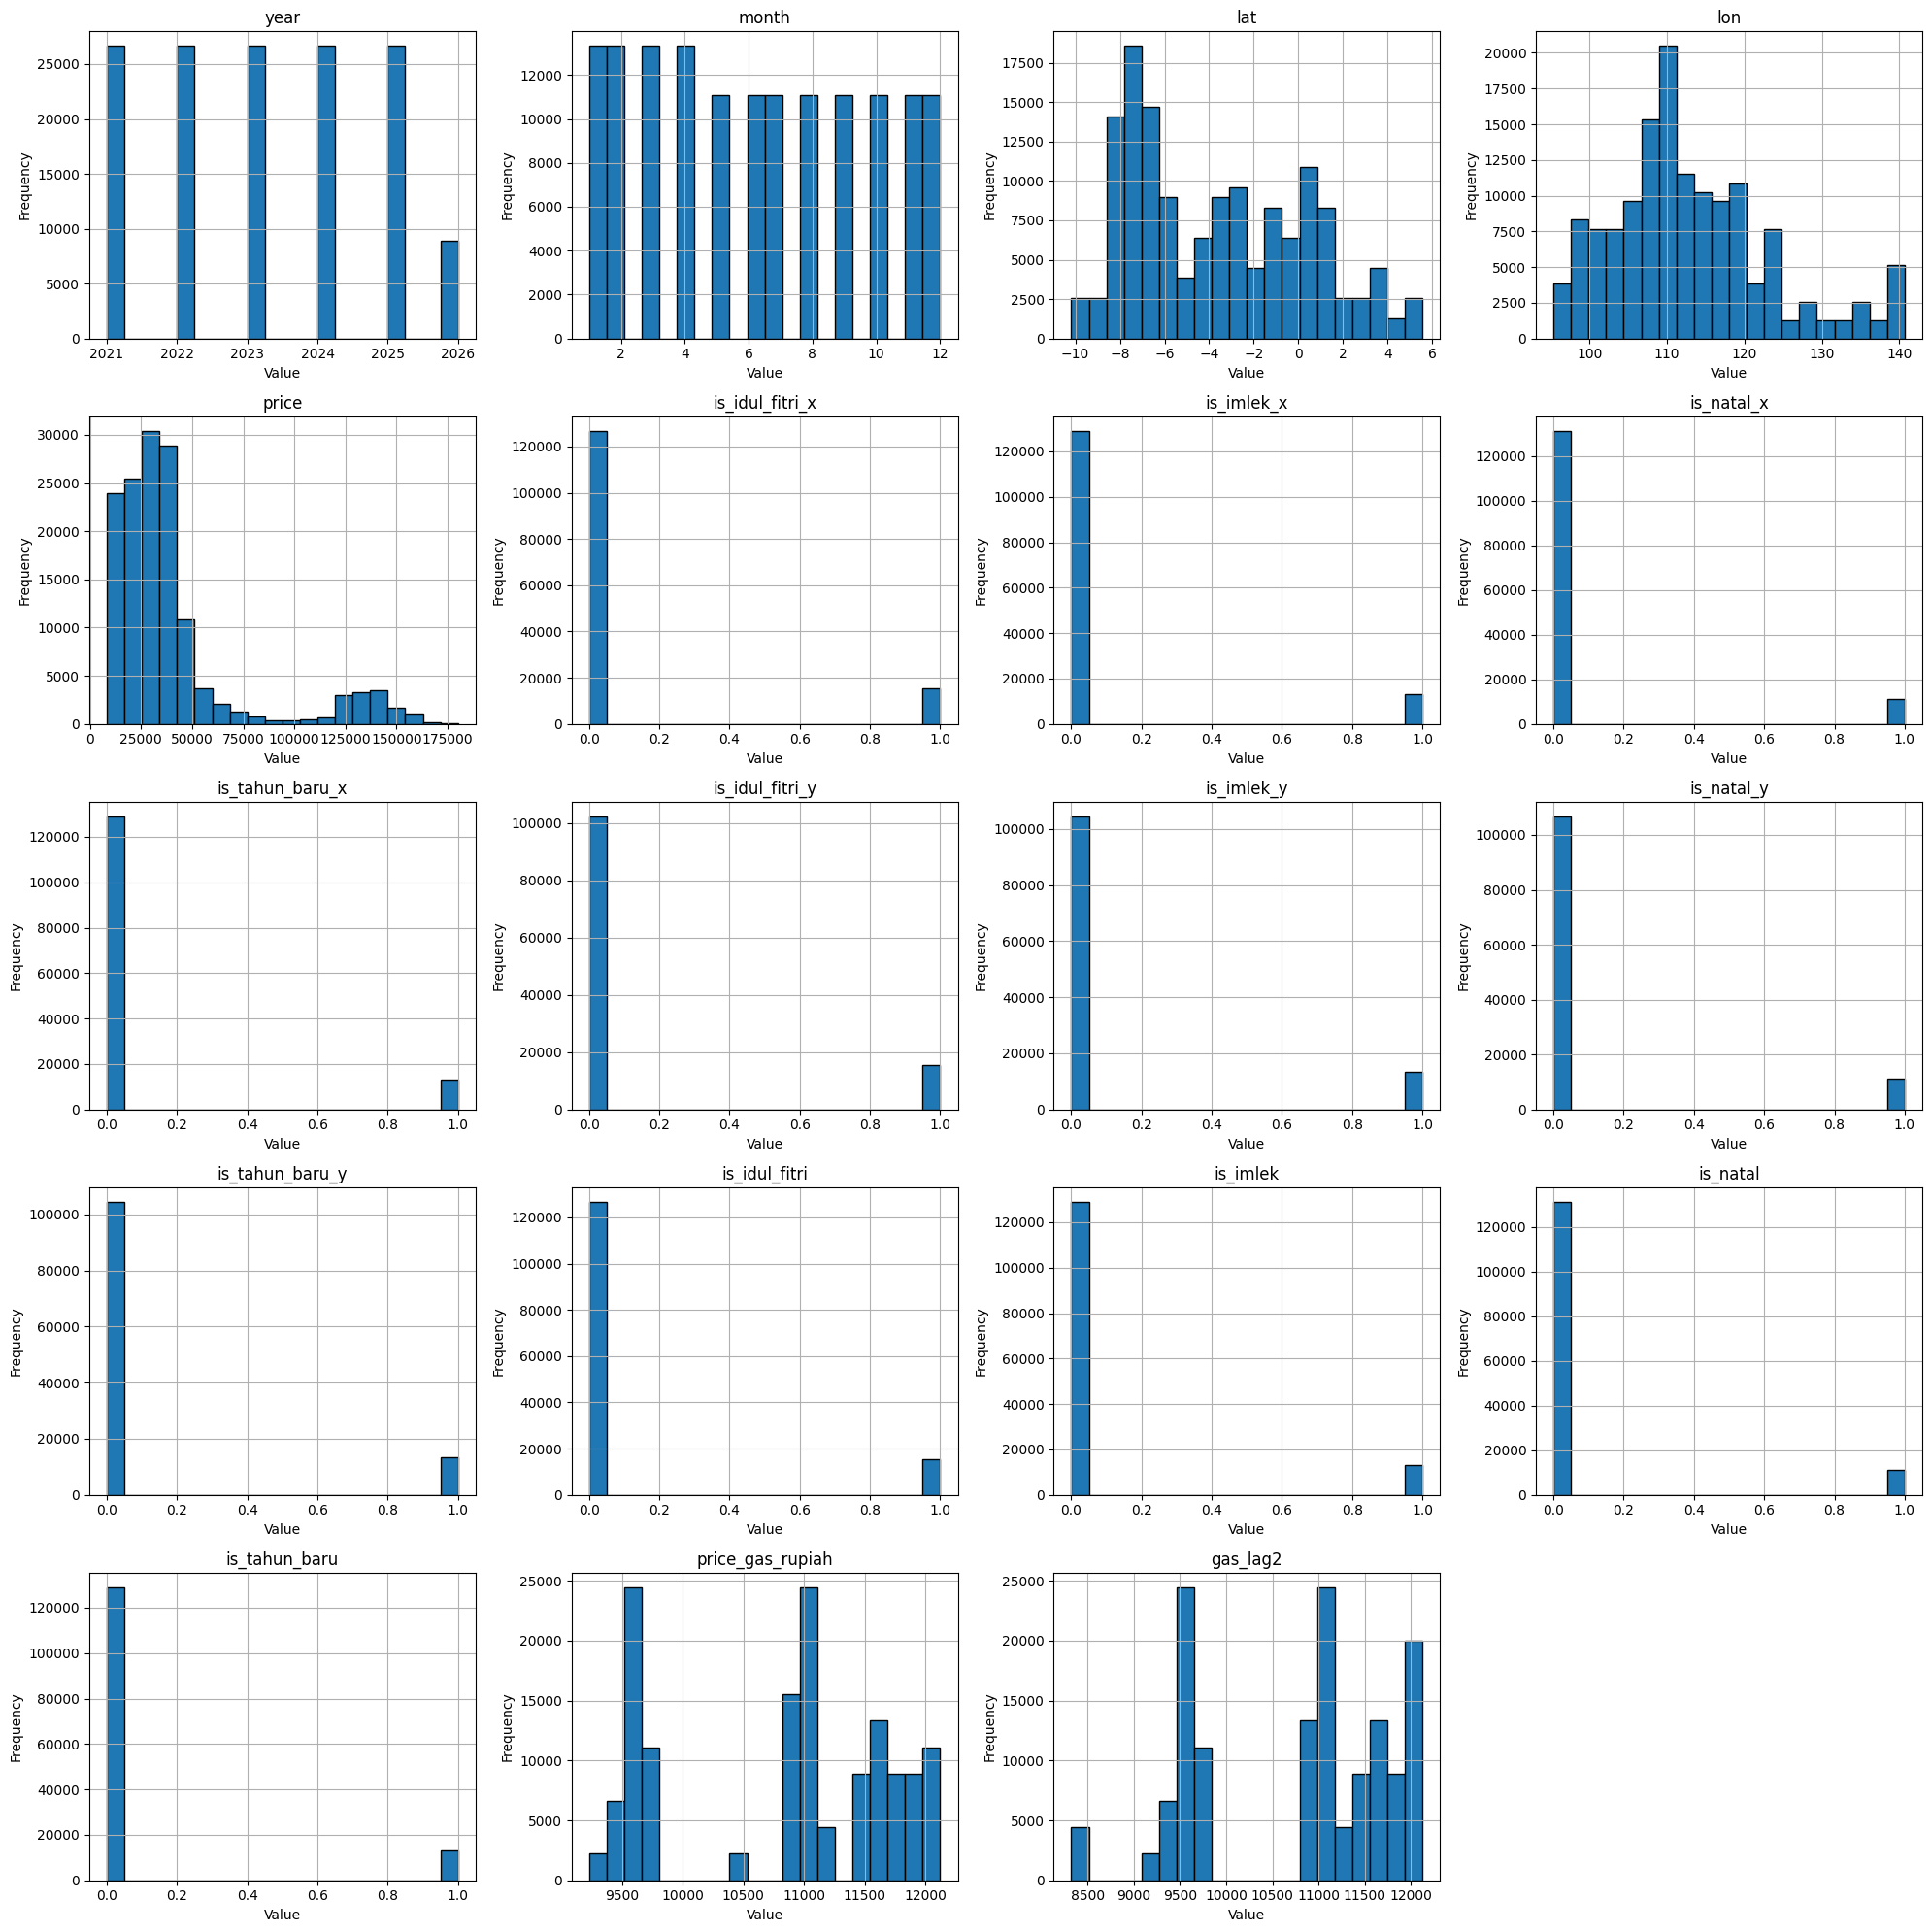

In [ ]:


# Ambil hanya kolom numerik
numeric_cols = df_eda.select_dtypes(include=np.number).columns

num_vars = len(numeric_cols)

n_cols = 4
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

axes = axes.flatten()

# Histogram hanya numerik
for i, column in enumerate(numeric_cols):
    df_eda[column].hist(
        ax=axes[i],
        bins=20,
        edgecolor='black'
    )

    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

INSIGHT: Distribusi harga bersifat right-skewed, menunjukkan sebagian kecil observasi memiliki harga sangat tinggi dibanding mayoritas data. Hal ini mengindikasikan adanya perbedaan harga signifikan antar komoditas maupun wilayah.

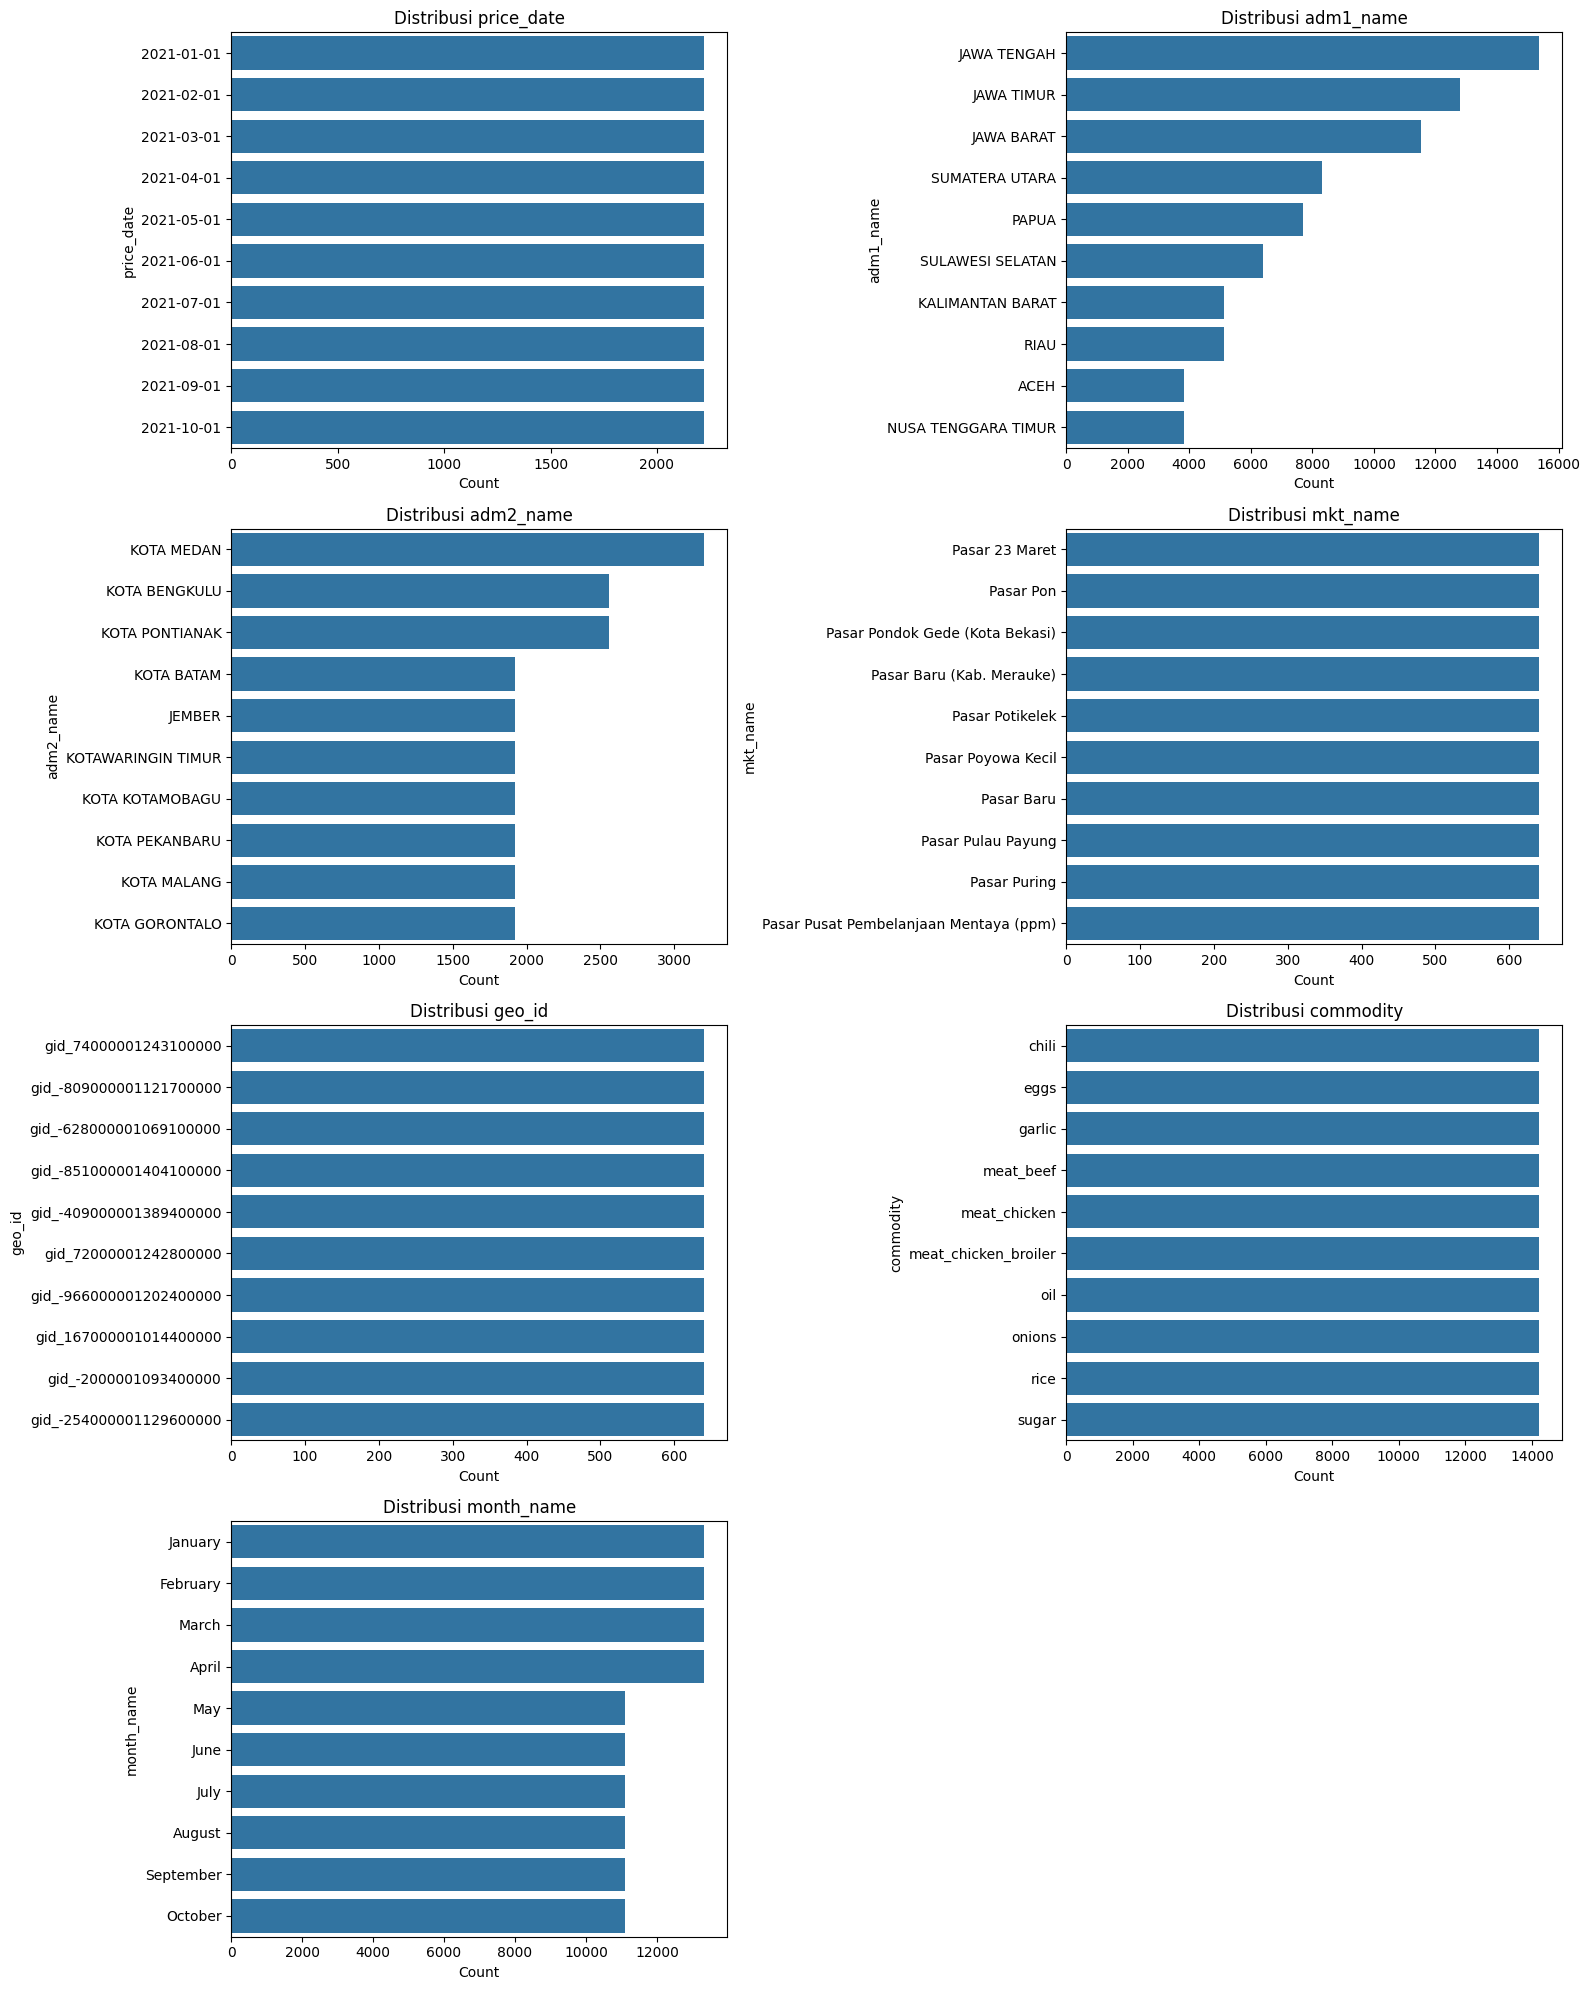

In [ ]:

# Ambil kolom kategorikal
categorical_cols = df_eda.select_dtypes(include='object').columns

num_vars = len(categorical_cols)

n_cols = 2
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 5)
)

axes = axes.flatten()

for i, column in enumerate(categorical_cols):

    # Ambil top 10 kategori agar tidak terlalu penuh
    top_categories = df_eda[column].value_counts().head(10)

    sns.countplot(
        y=df_eda[column],
        order=top_categories.index,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribusi {column}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(column)

# Hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

INSIGHT: Distribusi observasi antar wilayah tidak merata, sehingga model nantinya berpotensi lebih bias terhadap wilayah dengan jumlah data besar.

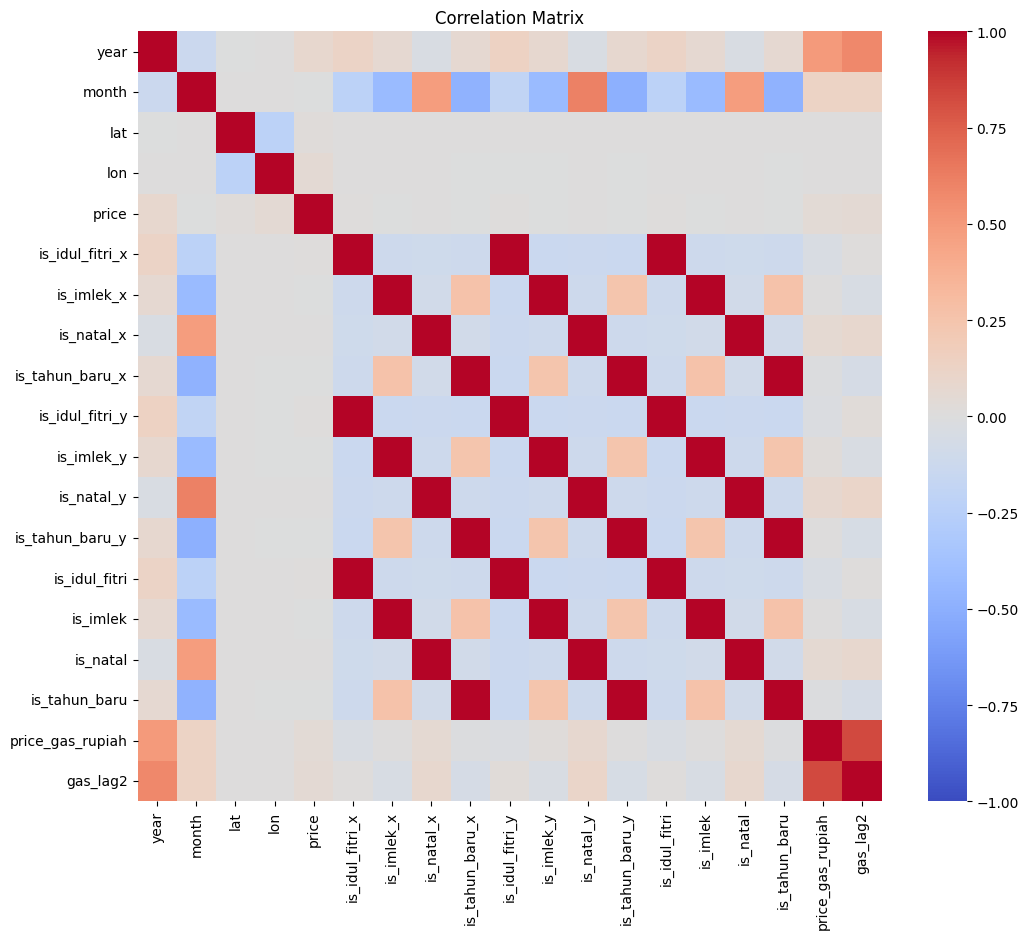

In [ ]:
#visualisasi korelasi data numerikal

plt.figure(figsize=(12,10))
df_numeric = df_eda.select_dtypes(include=[np.number])

correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

INSIGHT: Tidak ditemukan korelasi linear yang kuat antar variabel numerik.

In [ ]:
#cek korelasi variabel lain dg variabel price
correlation_matrix['price'].sort_values(ascending=False)

,price
price,1.000000
year,0.085805
lon,0.048649
gas_lag2,0.048581
price_gas_rupiah,0.041311
lat,0.023046
is_idul_fitri_y,0.012774
is_idul_fitri_x,0.011611
is_idul_fitri,0.011611
is_natal_y,0.002741


INSIGHT: Variabel numerik tidak menunjukkan hubungan linear kuat terhadap price, sehingga kemungkinan pola hubungan bersifat non-linear.

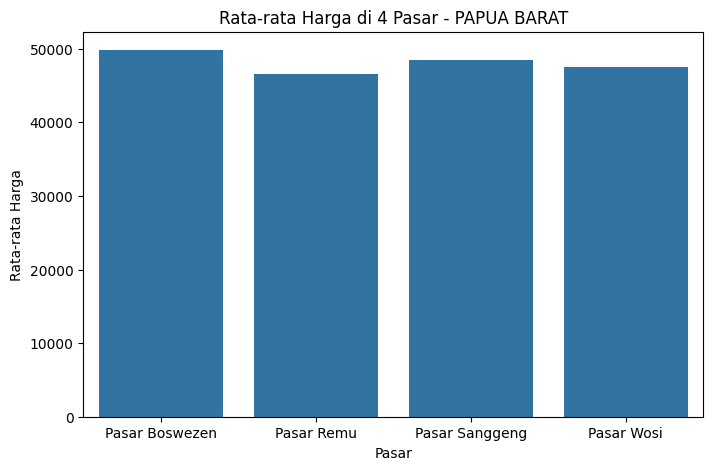

In [ ]:
#Bar Chart membandingkan rata-rata harga di pasar A vs pasar B dalam satu kota (ambil contoh aja) // 4 pasar

wilayah = 'PAPUA BARAT'
df_wilayah = df_eda[df_eda['adm1_name'] == wilayah]

top_market = df_wilayah['mkt_name'].value_counts().head(4).index

df_market = df_wilayah[df_wilayah['mkt_name'].isin(top_market)]

avg_price = df_market.groupby('mkt_name')['price'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_price,
    x='mkt_name',
    y='price'
)

plt.title(f'Rata-rata Harga di 4 Pasar - {wilayah}')
plt.xlabel('Pasar')
plt.ylabel('Rata-rata Harga')

plt.show()

INSIGHT: Terdapat perbedaan rata-rata harga antar pasar dalam wilayah yang sama, yang mengindikasikan adanya variasi distribusi harga lokal.

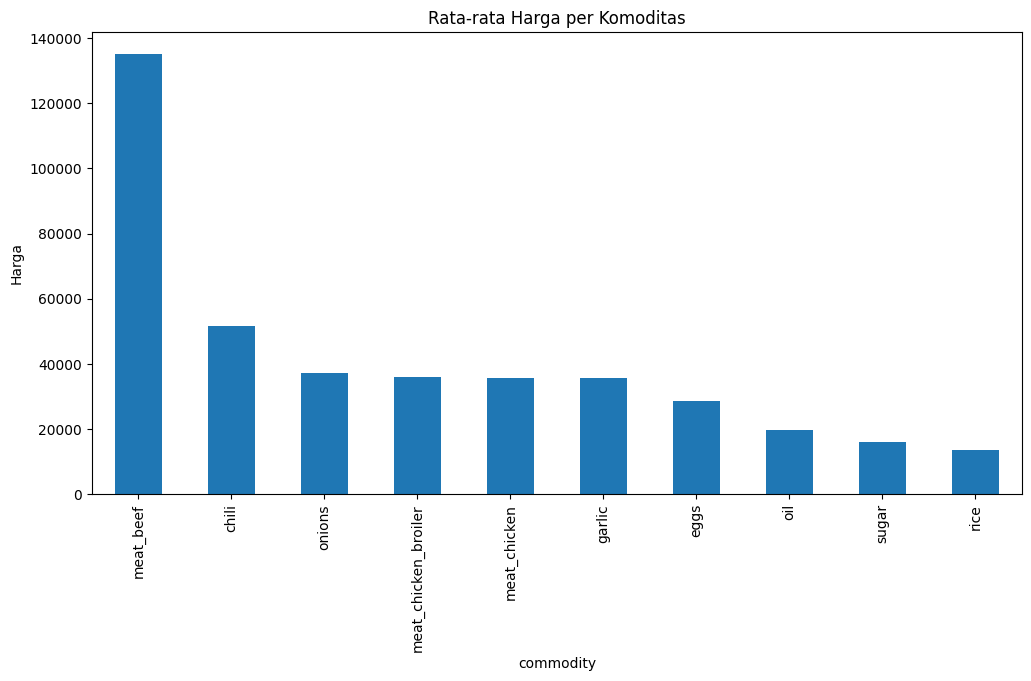

In [ ]:
avg_commodity = df_eda.groupby('commodity')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
avg_commodity.plot(kind='bar')
plt.title("Rata-rata Harga per Komoditas")
plt.ylabel("Harga")
plt.show()

INSIGHT: Komoditas tertentu memiliki rata-rata harga jauh lebih tinggi dibanding komoditas lain, menunjukkan adanya perbedaan karakteristik pasar antar komoditas.

Text(0.5, 1.0, '15 Provinsi dengan Rata-rata Harga Tertinggi')

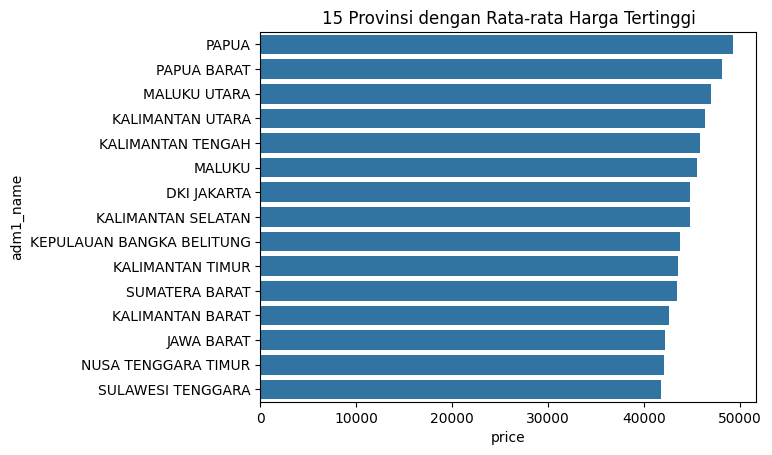

In [ ]:
#menampilkan informasi provinsi dengan rata-rata harga tertinggi
prov_avg = (
    df_eda.groupby("adm1_name")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(data=prov_avg.head(15), x="price", y="adm1_name")
plt.title("15 Provinsi dengan Rata-rata Harga Tertinggi")

INSIGHT: Beberapa provinsi memiliki rata-rata harga komoditas yang jauh lebih tinggi dibanding wilayah lain. Hal ini dapat dipengaruhi oleh faktor distribusi, logistik, kondisi geografis, maupun tingkat inflasi daerah tertentu

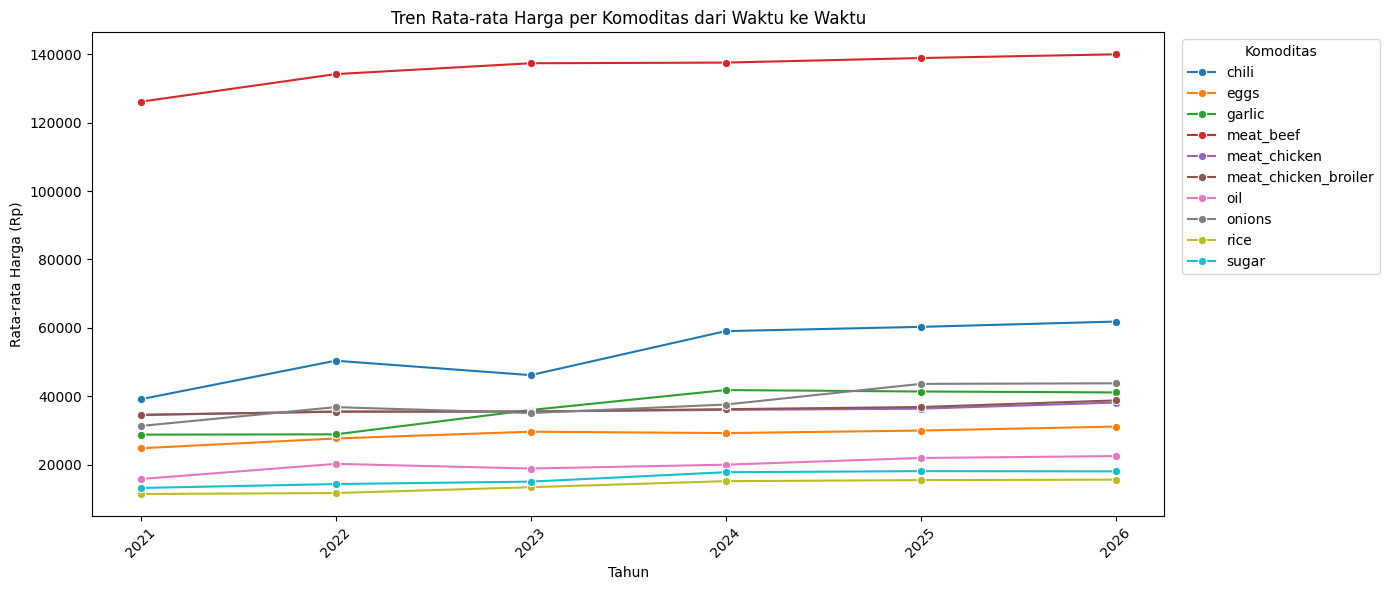

In [ ]:
# Tren harga rata-rata dari waktu ke waktu — per komoditas


price_trend = df_eda.groupby(["year", "commodity"])["price"].mean().reset_index()


plt.figure(figsize=(14, 6))
sns.lineplot(data=price_trend, x="year", y="price", hue="commodity", marker="o")
plt.title("Tren Rata-rata Harga per Komoditas dari Waktu ke Waktu")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Harga (Rp)")
plt.xticks(price_trend["year"].unique(), rotation=45)
plt.legend(title="Komoditas", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

INSIGHT: Harga rata-rata komoditas mengalami perubahan dari waktu ke waktu dengan pola tren tertentu, sehingga data memiliki potensi untuk digunakan pada model prediksi harga.

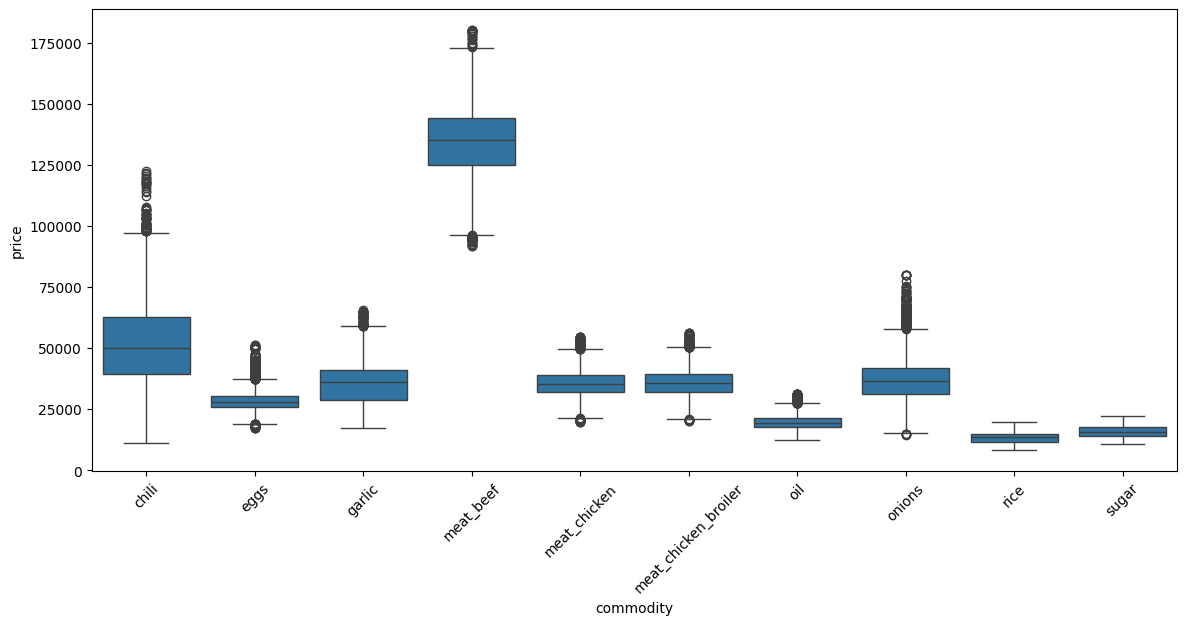

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(x='commodity', y='price', data=df_eda)
plt.xticks(rotation=45)
plt.show()

INSIGHT: Variasi harga antar komoditas cukup besar. Beberapa komoditas menunjukkan volatilitas harga tinggi yang terlihat dari rentang distribusi dan outlier yang lebar.

In [ ]:
# ==============================================================================
# FEATURE ENGINEERING (Fitur Waktu)
# ==============================================================================
def create_time_features(group):
    group = group.sort_values('price_date')   # pastikan urut waktu dalam tiap kelompok
    # Tren jangka pendek
    group['lag_1'] = group['price'].shift(1)
    group['lag_2'] = group['price'].shift(2)
    group['rolling_mean_3'] = group['price'].rolling(window=3).mean().shift(1)
    # Tren jangka panjang (musiman)
    group['lag_12'] = group['price'].shift(12)
    group['rolling_mean_12'] = group['price'].rolling(window=12).mean().shift(1)
    return group

df_long = df_long.groupby(['mkt_name', 'commodity'], group_keys=False).apply(create_time_features)

# Buang baris NaN akibat shift (awal tiap kelompok) + baris tanpa gas_lag2
df_siap_ml = df_long.dropna(
    subset=['lag_1', 'lag_2', 'rolling_mean_3', 'lag_12', 'rolling_mean_12', 'gas_lag2']
).reset_index(drop=True)

print("Jumlah baris siap latih:", len(df_siap_ml))

Jumlah baris siap latih: 115440


/tmp/ipykernel_2385/3590857244.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_long = df_long.groupby(['mkt_name', 'commodity'], group_keys=False).apply(create_time_features)


In [ ]:
df_siap_ml.head()

,price_date,year,month,adm1_name,adm2_name,mkt_name,lat,lon,geo_id,commodity,...,is_imlek,is_natal,is_tahun_baru,price_gas_rupiah,gas_lag2,lag_1,lag_2,rolling_mean_3,lag_12,rolling_mean_12
0,2022-01-01,2022,1,KALIMANTAN SELATAN,KOTA BANJARMASIN,Pasar Lama,-3.31,114.59,gid_-331000001145900000,chili,...,0,0,1,9590.35,9590.35,49657.97,42717.26,42708.410000,58100.64,49106.194167
1,2022-01-01,2022,1,SUMATERA UTARA,KOTA MEDAN,Pusat Pasar,3.59,98.69,gid_35900000986900000,chili,...,0,0,1,9590.35,9590.35,26928.75,30055.91,30836.993333,39316.20,30732.154167
2,2022-01-01,2022,1,GORONTALO,KOTA GORONTALO,Pasar Sentral (Kota Gorontalo),0.55,123.06,gid_55000001230600000,chili,...,0,0,1,9590.35,9590.35,37766.15,32272.73,34479.626667,43925.00,35139.434167
3,2022-01-01,2022,1,KEPULAUAN RIAU,KOTA BATAM,Pasar Aviari,1.05,103.97,gid_105000001039700000,chili,...,0,0,1,9590.35,9590.35,48617.65,58454.55,49572.713333,69075.00,44896.447500
4,2022-01-01,2022,1,JAMBI,KOTA JAMBI,Pasar Angso Duo Jambi,-1.59,103.61,gid_-159000001036100000,chili,...,0,0,1,9590.35,9590.35,28652.17,38113.64,30505.270000,39912.50,27964.050833


In [ ]:
# ==============================================================================
# 1) TRAIN-TEST SPLIT (sebelum encoding, berbasis waktu)
# ==============================================================================
df_siap_ml['price_date'] = pd.to_datetime(df_siap_ml['price_date'])
batas_waktu = '2025-01-01'

train_df = df_siap_ml[df_siap_ml['price_date'] < batas_waktu].copy()
test_df  = df_siap_ml[df_siap_ml['price_date'] >= batas_waktu].copy()
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

Train: 79920 | Test: 35520


In [ ]:
# ==============================================================================
# 2) ENCODING (per kolom, fit HANYA di train, kategori asing -> -1)
# ==============================================================================
kolom_teks = ['adm1_name', 'adm2_name', 'mkt_name', 'commodity']
label_encoders = {}

for kolom in kolom_teks:
    le = LabelEncoder()
    train_df[kolom] = le.fit_transform(train_df[kolom])
    test_df[kolom]  = test_df[kolom].map(
        lambda s: le.transform([s])[0] if s in le.classes_ else -1
    )
    label_encoders[kolom] = le

joblib.dump(label_encoders, 'label_encoders.pkl')
print("Encoder disimpan: label_encoders.pkl")

Encoder disimpan: label_encoders.pkl


In [ ]:
# ==============================================================================
# 3) PEMILIHAN FITUR & TARGET  (TANPA scaling — price tetap rupiah)
# ==============================================================================
kolom_fitur = [
    'adm1_name', 'adm2_name', 'mkt_name', 'commodity',        # lokasi & barang (encoded)
    'lag_1', 'lag_2', 'rolling_mean_3',                       # memori jangka pendek
    'lag_12', 'rolling_mean_12',                              # memori jangka panjang (musiman)
    'gas_lag2',                                               # indikator BBM (lag 2 bulan)
    'is_idul_fitri', 'is_imlek', 'is_natal', 'is_tahun_baru'  # hari besar
]

X_train, y_train = train_df[kolom_fitur], train_df['price']   # y dalam RUPIAH
X_test,  y_test  = test_df[kolom_fitur],  test_df['price']

In [ ]:
# === PERBAIKAN: validasi diambil dari DATA TRAIN untuk early stopping ===
dates_sorted = train_df['price_date'].sort_values()
batas_validasi = dates_sorted.iloc[int(len(dates_sorted) * 0.9)]
mask_val = train_df['price_date'] >= batas_validasi

X_tr,  y_tr  = X_train[~mask_val], y_train[~mask_val]
X_val, y_val = X_train[mask_val],  y_train[mask_val]
print(f"Train inti: {len(X_tr)} | Validasi: {len(X_val)} | Test: {len(X_test)}")

model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    random_state=42,
    early_stopping_rounds=50
)
model_xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],   # validasi dari TRAIN — test set tidak pernah dilihat saat training
    verbose=100
)
print("Training baseline selesai. Jumlah pohon terpakai:", model_xgb.best_iteration + 1)

Train inti: 71040 | Validasi: 8880 | Test: 35520
[0]	validation_0-rmse:33831.20914
[100]	validation_0-rmse:3194.40718
[200]	validation_0-rmse:2675.89006
[300]	validation_0-rmse:2556.35245
[400]	validation_0-rmse:2507.16655
[500]	validation_0-rmse:2478.79694
[600]	validation_0-rmse:2467.91850
[700]	validation_0-rmse:2463.02561
[800]	validation_0-rmse:2461.71120
[812]	validation_0-rmse:2461.95581
Training baseline selesai. Jumlah pohon terpakai: 763


In [ ]:
# ==============================================================================
# HYPERPARAMETER TUNING (TimeSeriesSplit di data train — bebas kebocoran)
# ==============================================================================
tscv = TimeSeriesSplit(n_splits=3)
param_grid = {
    'n_estimators':     [300, 500, 800],
    'learning_rate':    [0.01, 0.03, 0.05],
    'max_depth':        [3, 5, 7],
    'reg_lambda':       [1.0, 2.0, 5.0],
    'subsample':        [0.8],
    'colsample_bytree': [0.8],
}
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
grid_search = GridSearchCV(
    xgb_base, param_grid, cv=tscv,
    scoring='neg_mean_absolute_error',   # MAE: lebih tahan outlier (cabai/bawang yg ekstrem)
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print("Parameter terbaik:", grid_search.best_params_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Parameter terbaik: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 800, 'reg_lambda': 1.0, 'subsample': 0.8}


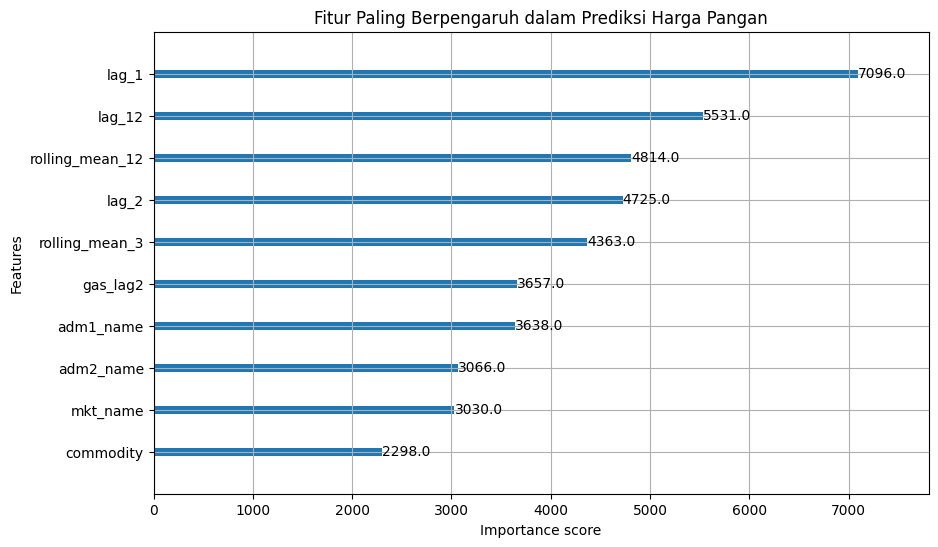

In [ ]:
# --- TAHAP 5: Visualisasi Feature Importance ---
plt.figure(figsize=(10, 6))
# Membuat plot batang untuk melihat fitur terpenting
xgb.plot_importance(model_xgb, importance_type='weight', max_num_features=10, ax=plt.gca())
plt.title('Fitur Paling Berpengaruh dalam Prediksi Harga Pangan')
plt.show()

# dari visualisasi didapatkan insight: model bukan sekedar meniru lag_1, tetapi benar-benar belajar dari pola musiman dan tren panjang.

In [ ]:
# Model final: latih ulang dgn parameter terbaik pada SELURUH train (test tetap bersih)
best_xgb_model = grid_search.best_estimator_
best_xgb_model.fit(X_train, y_train)

# Simpan SATU model final dengan nama yang jelas (ini yang dipakai dashboard)
joblib.dump(best_xgb_model, 'model_harga_pangan.pkl')
print("Model final disimpan: model_harga_pangan.pkl")

Model final disimpan: model_harga_pangan.pkl


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

y_pred = best_xgb_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print("=== Evaluasi Model (satuan RUPIAH) ===")
print(f"MAE  : Rp {mae:,.0f}")
print(f"RMSE : Rp {rmse:,.0f}")
print(f"MAPE : {mape*100:.2f}%")

# --- Baseline naif: 'harga bulan depan = harga bulan ini (lag_1)' ---
y_naive = X_test['lag_1']
mape_naive = mean_absolute_percentage_error(y_test, y_naive)
print(f"\nMAPE baseline naif (lag_1) : {mape_naive*100:.2f}%")
print("Model benar-benar berguna jika MAPE-nya jelas di bawah baseline naif.")

=== Evaluasi Model (satuan RUPIAH) ===
MAE  : Rp 1,426
RMSE : Rp 2,493
MAPE : 3.36%

MAPE baseline naif (lag_1) : 2.94%
Model benar-benar berguna jika MAPE-nya jelas di bawah baseline naif.


In [ ]:
# --- MAPE per komoditas (lihat komoditas volatil seperti cabai/bawang/ayam) ---
hasil = test_df.copy()
hasil['y_true'] = y_test.values
hasil['y_pred'] = y_pred
hasil['commodity_name'] = label_encoders['commodity'].inverse_transform(hasil['commodity'])

per_kom = (hasil.groupby('commodity_name')
           .apply(lambda d: mean_absolute_percentage_error(d['y_true'], d['y_pred']) * 100)
           .sort_values())
print("\nMAPE per komoditas (%):")
print(per_kom.round(2))


MAPE per komoditas (%):
commodity_name
meat_beef               1.10
sugar                   1.60
rice                    1.61
oil                     1.96
eggs                    2.75
meat_chicken            3.80
meat_chicken_broiler    3.91
garlic                  3.95
chili                   5.01
onions                  7.89
dtype: float64


/tmp/ipykernel_2385/4083606164.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: mean_absolute_percentage_error(d['y_true'], d['y_pred']) * 100)


# **MAPE** sedikit diatas **Baseline Naif**, artinya model masih dibatas lampu kuning, bukan lampu merah atau lampu hijau.


In [ ]:
# menjalankan diagnostik model dengan membandingkan MAPE model vs MODE naif dipisah per komoditas

import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error

hasil = test_df.copy()
hasil['y_true'] = y_test.values
hasil['y_pred_model'] = y_pred
hasil['y_pred_naif'] = X_test['lag_1'].values
hasil['commodity_name'] = label_encoders['commodity'].inverse_transform(hasil['commodity'])

def mape(d, kolom):
    return mean_absolute_percentage_error(d['y_true'], d[kolom]) * 100

ringkas = hasil.groupby('commodity_name').apply(
    lambda d: pd.Series({
        'MAPE_model': mape(d, 'y_pred_model'),
        'MAPE_naif':  mape(d, 'y_pred_naif'),
    })
)
ringkas['selisih (naif - model)'] = ringkas['MAPE_naif'] - ringkas['MAPE_model']
ringkas = ringkas.sort_values('selisih (naif - model)', ascending=False)
print(ringkas.round(2))
print("\n'selisih' positif = model MENGALAHKAN baseline naif untuk komoditas itu.")

                      MAPE_model  MAPE_naif  selisih (naif - model)
commodity_name                                                     
garlic                      3.95       3.81                   -0.14
meat_chicken                3.80       3.57                   -0.23
onions                      7.89       7.61                   -0.28
meat_chicken_broiler        3.91       3.62                   -0.29
meat_beef                   1.10       0.75                   -0.35
sugar                       1.60       1.16                   -0.44
rice                        1.61       1.14                   -0.47
eggs                        2.75       2.26                   -0.48
oil                         1.96       1.30                   -0.66
chili                       5.01       4.20                   -0.80

'selisih' positif = model MENGALAHKAN baseline naif untuk komoditas itu.


/tmp/ipykernel_2385/2898262102.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ringkas = hasil.groupby('commodity_name').apply(


# persistensi/naif adalah baseline yang kuat untuk harga pangan stabil, dan model kami setara dengannya

In [ ]:

# === VALIDASI PREDIKSI (versi pipeline baru — tanpa scaler) ===
import joblib
import pandas as pd

# 1. Kriteria pencarian (ganti sesuai data yang ada; pakai tanggal 2025 utk uji out-of-sample)
target_market = 'Pasar 23 Maret'
target_commodity = 'meat_chicken'      # nama tanpa prefix 'c_'
target_date = '2025-05-01'
target_date_dt = pd.to_datetime(target_date)

# 2. Cari baris di df_siap_ml
kondisi = (
    (df_siap_ml['mkt_name'] == target_market) &
    (df_siap_ml['commodity'] == target_commodity) &
    (df_siap_ml['price_date'] == target_date_dt)
)
sampel = df_siap_ml[kondisi].copy()

if sampel.empty:
    print("Data tidak ditemukan! Cek nama pasar, komoditas, atau tanggal.")
else:
    # a. Muat artefak yang dipakai dashboard (TANPA scaler)
    model = joblib.load('model_harga_pangan.pkl')
    label_encoders = joblib.load('label_encoders.pkl')

    # b. Encode kategori (kategori asing -> -1)
    kolom_teks = ['adm1_name', 'adm2_name', 'mkt_name', 'commodity']
    for col in kolom_teks:
        sampel[col] = sampel[col].map(
            lambda s: label_encoders[col].transform([s])[0] if s in label_encoders[col].classes_ else -1
        )

    # c. Susun fitur (urutan & isi HARUS sama dengan training) — tanpa scaling
    kolom_fitur = [
        'adm1_name', 'adm2_name', 'mkt_name', 'commodity',
        'lag_1', 'lag_2', 'rolling_mean_3', 'lag_12', 'rolling_mean_12',
        'gas_lag2',
        'is_idul_fitri', 'is_imlek', 'is_natal', 'is_tahun_baru'
    ]
    X_uji = sampel[kolom_fitur]

    # d. Prediksi langsung dalam RUPIAH (tidak perlu inverse_transform)
    harga_prediksi = model.predict(X_uji)[0]

    # e. Bandingkan dengan harga aktual
    baris = df_siap_ml[kondisi].iloc[0]
    harga_asli = baris['price']

    print("=" * 50)
    print("VALIDASI PREDIKSI MODEL XGBOOST")
    print("=" * 50)
    print(f"Pasar          : {baris['mkt_name']}")
    print(f"Komoditas      : {baris['commodity']}")
    print(f"Tanggal        : {baris['price_date'].date()}")
    print("-" * 50)
    print(f"Harga Aktual   : Rp {harga_asli:,.0f}")
    print(f"Harga Prediksi : Rp {harga_prediksi:,.0f}")
    selisih = abs(harga_asli - harga_prediksi)
    err = (selisih / harga_asli) * 100 if harga_asli != 0 else 0
    print("-" * 50)
    print(f"Selisih        : Rp {selisih:,.0f}")
    print(f"Error          : {err:.2f}%")
    print("=" * 50)

VALIDASI PREDIKSI MODEL XGBOOST
Pasar          : Pasar 23 Maret
Komoditas      : meat_chicken
Tanggal        : 2025-05-01
--------------------------------------------------
Harga Aktual   : Rp 34,678
Harga Prediksi : Rp 33,856
--------------------------------------------------
Selisih        : Rp 822
Error          : 2.37%


In [ ]:
df_siap_ml.to_csv('dataset_bersih.csv', index=False)
print("Data per-pasar lengkap disimpan: dataset_bersih.csv (untuk dashboard)")

Data per-pasar lengkap disimpan: dataset_bersih.csv (untuk dashboard)
